In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
filename = "GEOS-CF_AirQuality_20180101_0030z.nc4"

ds = xr.open_dataset(filename)

ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

In [4]:
lat = ds["lat"].values
lon = ds["lon"].values

# Select the first time and vertical level
O3 = ds["O3"].isel(time=0, lev=0).values

# Convert mol/mol to parts per billion
O3_ppb = O3 * 1e9

print(O3_ppb.shape)
print("Minimum O3:", np.nanmin(O3_ppb), "ppb")
print("Maximum O3:", np.nanmax(O3_ppb), "ppb")

(721, 1440)
Minimum O3: 0.0 ppb
Maximum O3: 69.73278 ppb


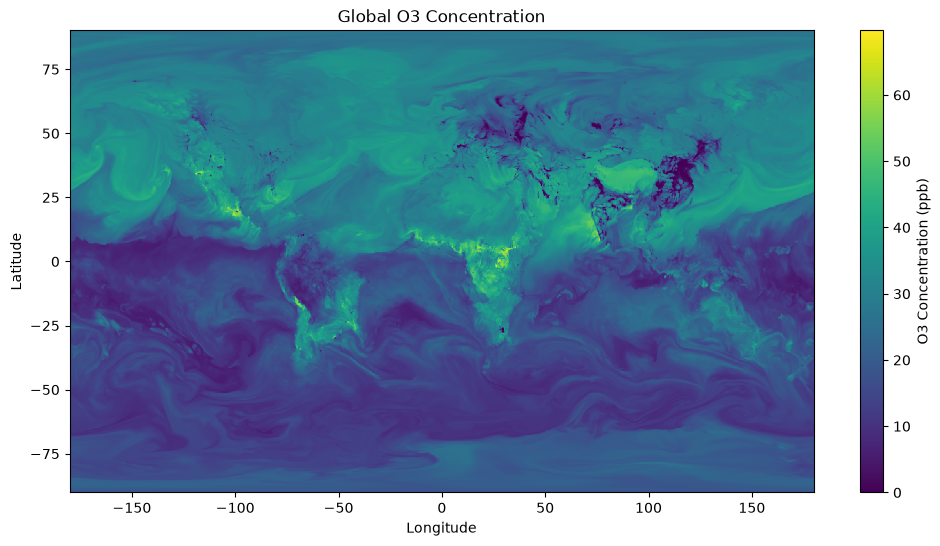

In [5]:
plt.figure(figsize=(12, 6))

plt.pcolormesh(lon, lat, O3_ppb, shading="auto")
plt.colorbar(label="O3 Concentration (ppb)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Global O3 Concentration")

plt.show()

In [6]:
max_index = np.unravel_index(np.nanargmax(O3_ppb), O3_ppb.shape)

max_lat = lat[max_index[0]]
max_lon = lon[max_index[1]]
max_O3 = O3_ppb[max_index]

print("Maximum O3 concentration:", max_O3, "ppb")
print("Latitude:", max_lat)
print("Longitude:", max_lon)

Maximum O3 concentration: 69.73278 ppb
Latitude: 34.5
Longitude: -118.75


In [7]:
min_index = np.unravel_index(np.nanargmin(O3_ppb), O3_ppb.shape)

min_lat = lat[min_index[0]]
min_lon = lon[min_index[1]]
min_O3 = O3_ppb[min_index]

print("Minimum O3 concentration:", min_O3, "ppb")
print("Latitude:", min_lat)
print("Longitude:", min_lon)

Minimum O3 concentration: 0.0 ppb
Latitude: 53.0
Longitude: 73.25


In [8]:
def get_nearest_O3(target_lat, target_lon):
    
    lat_index = np.abs(lat - target_lat).argmin()
    lon_index = np.abs(lon - target_lon).argmin()
    
    concentration = O3_ppb[lat_index, lon_index]
    
    return concentration, lat[lat_index], lon[lon_index]

In [9]:
LA_O3, LA_lat, LA_lon = get_nearest_O3(34.05, -118.24)

print("O3 over Los Angeles:", LA_O3, "ppb")
print("Grid latitude:", LA_lat)
print("Grid longitude:", LA_lon)

O3 over Los Angeles: 45.401974 ppb
Grid latitude: 34.0
Grid longitude: -118.25


In [10]:
Hawaii_O3, Hawaii_lat, Hawaii_lon = get_nearest_O3(21.31, -157.86)

print("O3 over Hawaii:", Hawaii_O3, "ppb")
print("Grid latitude:", Hawaii_lat)
print("Grid longitude:", Hawaii_lon)

O3 over Hawaii: 35.50667 ppb
Grid latitude: 21.25
Grid longitude: -157.75


Ozone Analysis Questions

a. Where is O3 qualitatively high?**

O3 appears relatively high in parts of North America, especially around Southern California. There are also other regions of elevated O3 visible across the Northern Hemisphere.

b. What latitude and longitude is O3 highest?**

The highest O3 concentration is about 69.73 ppb and occurs at approximately 34.5° N, 118.75° W.

c. Where is O3 qualitatively low?**

O3 is generally lower over many remote ocean regions and some parts of the tropics compared with the higher-concentration continental regions.

d. What latitude and longitude is O3 lowest?**

The minimum value in the dataset is 0 ppb at approximately 53.0° N, 73.25° E.

e. What is the O3 concentration over LA?**

Using the grid point closest to Los Angeles, the O3 concentration is approximately 45.4 ppb.

f. What is the O3 concentration over Hawaii?**

Using Honolulu as a representative location for Hawaii, the O3 concentration is approximately 35.5 ppb.

Final Project Pitch

Proposed Project: River Flow, Erosion, and Pipeline Risk

Data:

For my final project, I would like to use river data from the United States Geological Survey (USGS). USGS operates stream gauges throughout the United States that record measurements such as river discharge and gauge height over time.

I would select one river or watershed where erosion or river movement could potentially affect nearby infrastructure such as pipelines. I would download several years of daily streamflow data from one or more USGS stream gauges. Depending on the site and time period selected, this could give me several thousand daily observations to work with.

Analysis:

I would investigate how river conditions change over time and identify periods of unusually high discharge. I am interested in looking at whether large flow events could be used as an indicator of conditions where increased river erosion or scour may occur.

One possible analysis would be to compare river discharge through time and identify extreme flow events. I could also use regression to investigate relationships between variables such as gauge height and discharge. If multiple USGS stations are available along the same river, I could compare conditions between different locations.

The main goal would be to determine whether USGS river data can be used to identify locations or time periods where river conditions may create a greater potential for erosion.

Scientific Importance:

River erosion and scour can be important hazards for infrastructure located near or underneath rivers. For example, erosion can remove sediment surrounding buried pipelines and potentially expose or damage them.

I have previously done some work involving river erosion and how it can endanger pipelines, so I think this project would allow me to connect that experience with my new Geological Sciences major. Understanding how streamflow changes relate to erosion could be useful for identifying periods when rivers may pose a greater risk to nearby infrastructure.